<a href="https://colab.research.google.com/github/AmanuelDaget/Military-Aircraft-Recognition-Using-YOLO12/blob/main/Military_Aircraft_detection_from_Satellite_image_using_YOLO12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Military Aircraft Detection from Satellite image Using YOLO12: by Amanuel D**

**Install libraries**

In [1]:
!pip install ultralytics
!pip install lxml
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.2 MB/s eta 0:00:00


**Import libraries**

In [2]:
import os
import cv2
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xml.etree.ElementTree as ET

from tqdm import tqdm
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import torch
import torch.nn as nn
import torch.optim as optim

from collections import Counter

from torchvision import transforms
from torchvision import datasets
from torchvision import models
from torch.utils.data import DataLoader

from ultralytics import YOLO


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


**Mount Google Drive**

In [4]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


**Copy dataset from Drive**

In [5]:
!cp "/content/drive/MyDrive/Colab Notebooks/MAR20.zip" /content/

Unzip the dataset
**bold text**

In [6]:
!unzip -q /content/MAR20.zip -d /content/MAR20

In [7]:
base_path = "/content/MAR20"

print(os.listdir(base_path))

['ImageSets', 'Annotations', 'JPEGImages']


**Define Dataset Paths**

In [8]:
BASE_DIR = "/content/MAR20"

IMAGE_DIR = os.path.join(BASE_DIR, "JPEGImages")

ANNOTATION_DIR = os.path.join(
    BASE_DIR,
    "Annotations",
    "Horizontal Bounding Boxes"
)

**`Read All Image IDs`**

In [9]:
all_image_ids = []

for file in os.listdir(ANNOTATION_DIR):

    if file.endswith('.xml'):

        image_id = file.replace('.xml', '')

        all_image_ids.append(image_id)

print("Total Images:", len(all_image_ids))

Total Images: 3842


**Create Clean Dataset Folders**

In [10]:
os.makedirs(
    '/content/cleaned_dataset/images',
    exist_ok=True
)

os.makedirs(
    '/content/cleaned_dataset/annotations',
    exist_ok=True
)

**Dataset Cleaning**

In [11]:
valid_ids = []
bad_files = []

MIN_BOX_SIZE = 5

for image_id in tqdm(all_image_ids):

    image_path = os.path.join(
        IMAGE_DIR,
        image_id + '.jpg'
    )

    xml_path = os.path.join(
        ANNOTATION_DIR,
        image_id + '.xml'
    )

    # Check file existence
    if not os.path.exists(image_path):
        bad_files.append(image_id)
        continue

    if not os.path.exists(xml_path):
        bad_files.append(image_id)
        continue

    # Check image readability
    image = cv2.imread(image_path)

    if image is None:
        bad_files.append(image_id)
        continue

    # Validate XML
    try:

        root = ET.parse(xml_path).getroot()

        valid_annotation = True

        for obj in root.findall('object'):

            bbox = obj.find('bndbox')

            xmin = int(bbox.find('xmin').text)
            ymin = int(bbox.find('ymin').text)
            xmax = int(bbox.find('xmax').text)
            ymax = int(bbox.find('ymax').text)

            # Invalid boxes
            if xmin >= xmax or ymin >= ymax:
                valid_annotation = False
                break

            # Remove tiny boxes
            if (xmax - xmin) < MIN_BOX_SIZE:
                valid_annotation = False
                break

            if (ymax - ymin) < MIN_BOX_SIZE:
                valid_annotation = False
                break

        if valid_annotation:

            valid_ids.append(image_id)

            shutil.copy(
                image_path,
                '/content/cleaned_dataset/images'
            )

            shutil.copy(
                xml_path,
                '/content/cleaned_dataset/annotations'
            )

        else:
            bad_files.append(image_id)

    except:
        bad_files.append(image_id)

print("Valid Images:", len(valid_ids))
print("Bad Files:", len(set(bad_files)))

100%|██████████| 3842/3842 [00:33<00:00, 114.65it/s]

Valid Images: 3841
Bad Files: 1


**Update Dataset Paths**

In [12]:
IMAGE_DIR = '/content/cleaned_dataset/images'

ANNOTATION_DIR = '/content/cleaned_dataset/annotations'

**Create 70/15/15 Train/Val/Test Split**

In [13]:
train_ids, temp_ids = train_test_split(
    valid_ids,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

val_ids, test_ids = train_test_split(
    temp_ids,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print("Training Images:", len(train_ids))
print("Validation Images:", len(val_ids))
print("Test Images (Unseen):", len(test_ids))

Training Images: 2688
Validation Images: 576
Test Images (Unseen): 577


**Analyze Class Distribution**

In [14]:
class_counts = Counter()

for xml_file in os.listdir(ANNOTATION_DIR):

    xml_path = os.path.join(
        ANNOTATION_DIR,
        xml_file
    )

    root = ET.parse(xml_path).getroot()

    for obj in root.findall('object'):

        class_name = obj.find('name').text

        class_counts[class_name] += 1

print(class_counts)

Counter({'A16': 2632, 'A14': 1778, 'A2': 1728, 'A13': 1652, 'A1': 1646, 'A17': 1397, 'A5': 1262, 'A19': 1236, 'A3': 1176, 'A9': 1083, 'A20': 981, 'A8': 944, 'A10': 924, 'A12': 702, 'A7': 679, 'A4': 642, 'A15': 618, 'A11': 507, 'A6': 441, 'A18': 308})


**Plot Class Distribution**

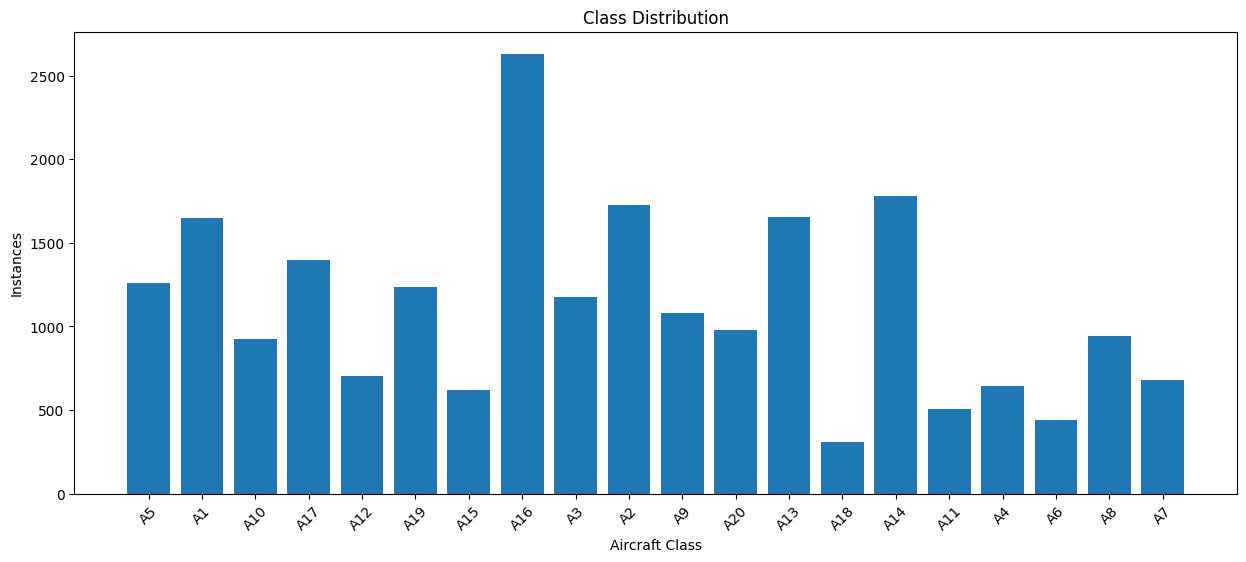

In [15]:
classes = list(class_counts.keys())
counts = list(class_counts.values())

plt.figure(figsize=(15,6))

plt.bar(classes, counts)

plt.xticks(rotation=45)

plt.xlabel('Aircraft Class')
plt.ylabel('Instances')
plt.title('Class Distribution')

plt.show()

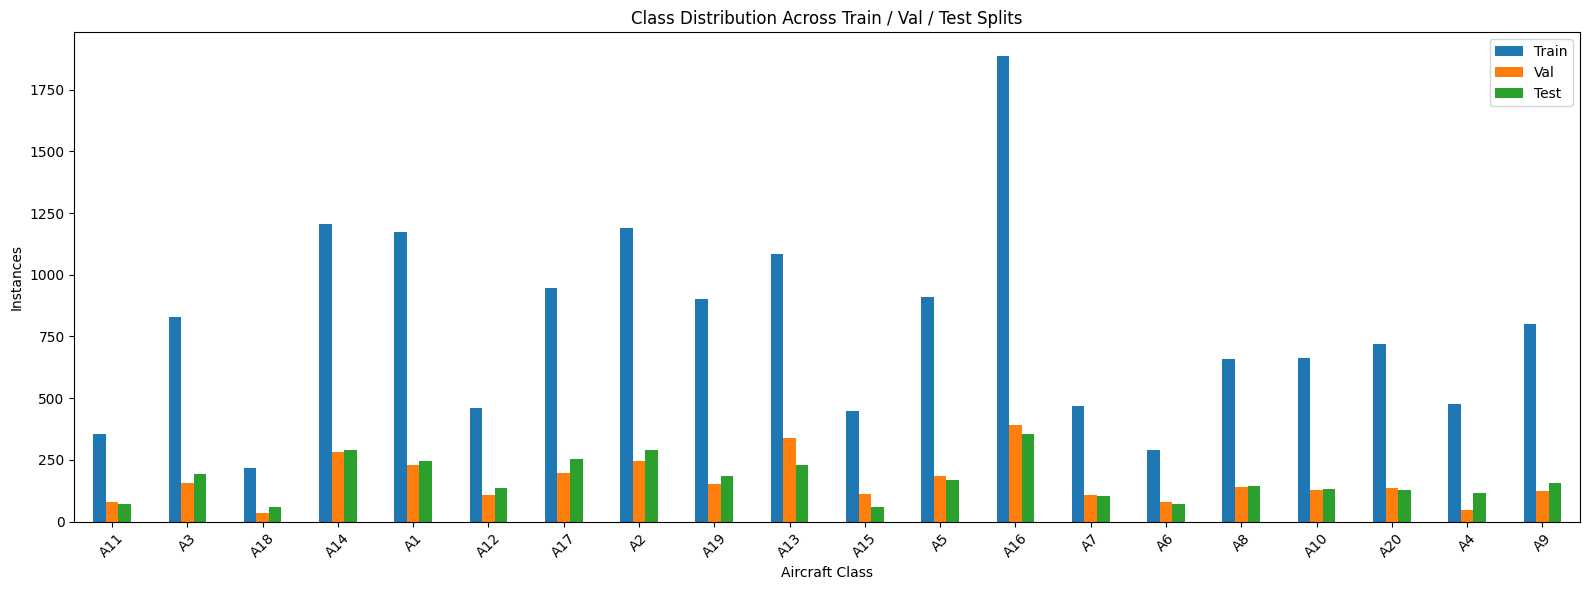

In [16]:
# Count classes per split
def count_classes_in_split(split_ids):
    counts = Counter()
    for image_id in split_ids:
        xml_path = os.path.join(ANNOTATION_DIR, image_id + '.xml')
        root = ET.parse(xml_path).getroot()
        for obj in root.findall('object'):
            counts[obj.find('name').text] += 1
    return counts

train_counts = count_classes_in_split(train_ids)
val_counts   = count_classes_in_split(val_ids)
test_counts  = count_classes_in_split(test_ids)

split_df = pd.DataFrame({
    'Train': train_counts,
    'Val':   val_counts,
    'Test':  test_counts
}).fillna(0).astype(int)

split_df.plot(kind='bar', figsize=(16, 6))
plt.title("Class Distribution Across Train / Val / Test Splits")
plt.xlabel("Aircraft Class")
plt.ylabel("Instances")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

**Visualize Random Samples**

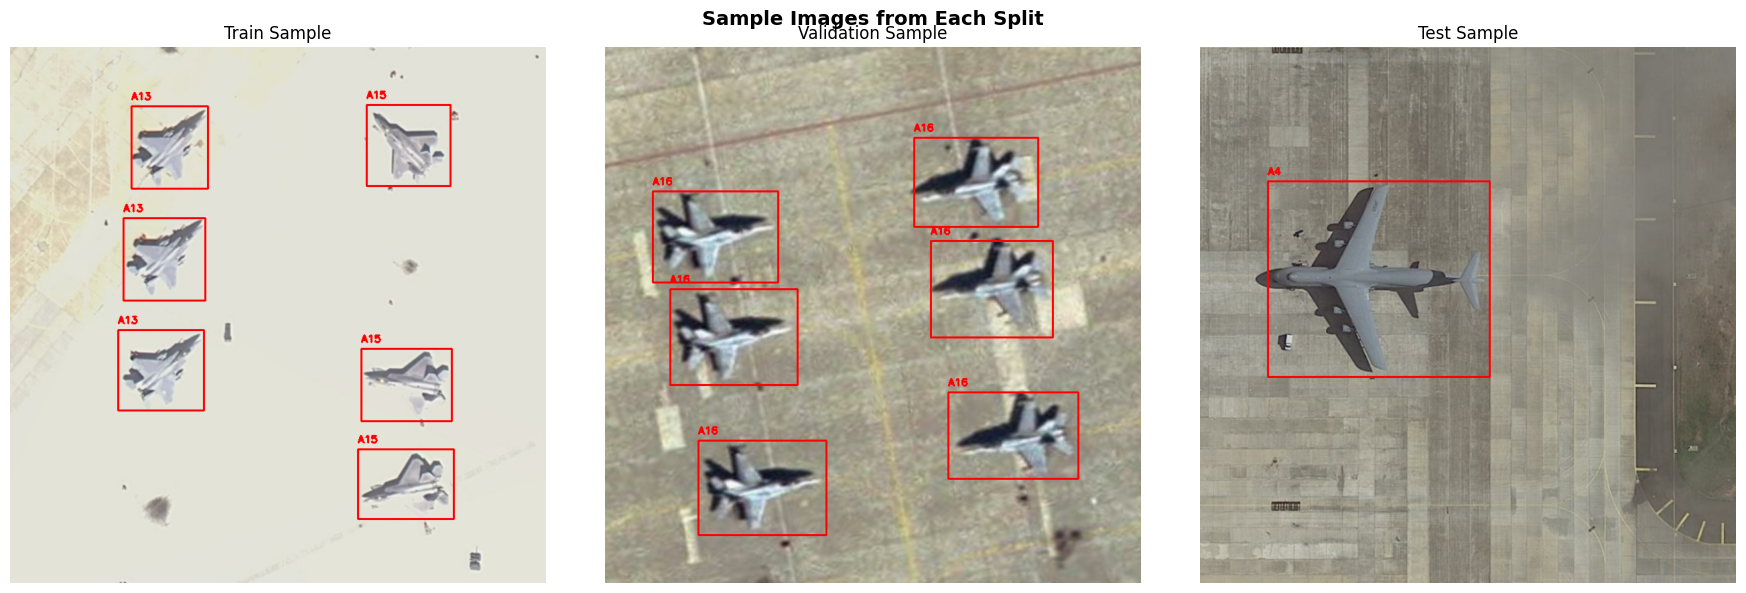

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Sample Images from Each Split", fontsize=14, fontweight='bold')

for ax, (split_name, split_ids) in zip(
    axes,
    [("Train", train_ids), ("Validation", val_ids), ("Test", test_ids)]
):
    sample_id = random.choice(split_ids)
    image_path = os.path.join(IMAGE_DIR, sample_id + '.jpg')
    xml_path = os.path.join(ANNOTATION_DIR, sample_id + '.xml')

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    root = ET.parse(xml_path).getroot()
    for obj in root.findall('object'):
        class_name = obj.find('name').text
        bbox = obj.find('bndbox')
        xmin = int(bbox.find('xmin').text)
        ymin = int(bbox.find('ymin').text)
        xmax = int(bbox.find('xmax').text)
        ymax = int(bbox.find('ymax').text)

        cv2.rectangle(image, (xmin, ymin), (xmax, ymax), (255, 0, 0), 2)
        cv2.putText(image, class_name, (xmin, ymin - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    ax.imshow(image)
    ax.set_title(f"{split_name} Sample")
    ax.axis('off')

plt.tight_layout()
plt.show()

**Create YOLO Dataset Structure**

In [18]:
os.makedirs('/content/yolo_dataset/images/train', exist_ok=True)
os.makedirs('/content/yolo_dataset/images/val', exist_ok=True)
os.makedirs('/content/yolo_dataset/images/test', exist_ok=True)

os.makedirs('/content/yolo_dataset/labels/train', exist_ok=True)
os.makedirs('/content/yolo_dataset/labels/val', exist_ok=True)
os.makedirs('/content/yolo_dataset/labels/test', exist_ok=True)

**Create Class Mapping**

In [19]:
classes = sorted(list(class_counts.keys()))

class_to_id = {
    cls:i for i, cls in enumerate(classes)
}

id_to_class = {
    i:cls for cls, i in class_to_id.items()
}

print(class_to_id)

{'A1': 0, 'A10': 1, 'A11': 2, 'A12': 3, 'A13': 4, 'A14': 5, 'A15': 6, 'A16': 7, 'A17': 8, 'A18': 9, 'A19': 10, 'A2': 11, 'A20': 12, 'A3': 13, 'A4': 14, 'A5': 15, 'A6': 16, 'A7': 17, 'A8': 18, 'A9': 19}


**Convert XML to YOLO Format**

In [20]:
def convert_to_yolo(size, box):

    w, h = size

    xmin, ymin, xmax, ymax = box

    x_center = ((xmin + xmax) / 2) / w
    y_center = ((ymin + ymax) / 2) / h

    width = (xmax - xmin) / w
    height = (ymax - ymin) / h

    return (
        x_center,
        y_center,
        width,
        height
    )

Convert Entire Dataset

In [21]:
def process_dataset(image_ids, split='train'):

    for image_id in tqdm(image_ids):

        image_file = image_id + '.jpg'
        xml_file = image_id + '.xml'

        image_path = os.path.join(
            IMAGE_DIR,
            image_file
        )

        xml_path = os.path.join(
            ANNOTATION_DIR,
            xml_file
        )

        image = cv2.imread(image_path)

        h, w, _ = image.shape

        label_lines = []

        root = ET.parse(xml_path).getroot()

        for obj in root.findall('object'):

            class_name = obj.find('name').text

            class_id = class_to_id[class_name]

            bbox = obj.find('bndbox')

            xmin = int(bbox.find('xmin').text)
            ymin = int(bbox.find('ymin').text)
            xmax = int(bbox.find('xmax').text)
            ymax = int(bbox.find('ymax').text)

            yolo_box = convert_to_yolo(
                (w,h),
                (xmin,ymin,xmax,ymax)
            )

            label_line = (
                f"{class_id} " +
                " ".join(map(str, yolo_box))
            )

            label_lines.append(label_line)

        shutil.copy(
            image_path,
            f'/content/yolo_dataset/images/{split}/{image_file}'
        )

        with open(
            f'/content/yolo_dataset/labels/{split}/{image_id}.txt',
            'w'
        ) as f:

            f.write('\n'.join(label_lines))

**Process Train and Validation Sets**

In [22]:
process_dataset(train_ids, split='train')
process_dataset(val_ids, split='val')
process_dataset(test_ids, split='test')

100%|██████████| 577/577 [00:05<00:00, 106.72it/s]


**Create YOLO YAML File**

In [23]:
yaml_content = f"""
path: /content/yolo_dataset

train: images/train
val: images/val
test: images/test

names:
"""
for i, cls in enumerate(classes):
    yaml_content += f'  {i}: {cls}\n'

with open('/content/yolo_dataset/dataset.yaml', 'w') as f:
    f.write(yaml_content)

print("YAML saved:")
print(yaml_content)

YAML saved:

path: /content/yolo_dataset

train: images/train
val: images/val
test: images/test

names:
  0: A1
  1: A10
  2: A11
  3: A12
  4: A13
  5: A14
  6: A15
  7: A16
  8: A17
  9: A18
  10: A19
  11: A2
  12: A20
  13: A3
  14: A4
  15: A5
  16: A6
  17: A7
  18: A8
  19: A9



Load YOLO12 Model

In [24]:
model = YOLO('yolo12n.pt')

**Train YOLO12**

In [25]:
model.train(
    data='/content/yolo_dataset/dataset.yaml',
    epochs=30,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    patience=10,
    optimizer='AdamW',
    lr0=0.001,
    pretrained=True,
    cache=True,
    amp=True,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.2
)

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/dataset.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=10

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ede6c4f8530>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043

**Load Best Trained Model**

In [26]:
# Load best trained model
model = YOLO("/content/runs/detect/train/weights/best.pt")

** Evaluate on Validation Set**

In [27]:
print("=== Validation Set Evaluation ===")
val_metrics = model.val(
    data='/content/yolo_dataset/dataset.yaml',
    split='val'
)
print(val_metrics)

=== Validation Set Evaluation ===
Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12n summary (fused): 159 layers, 2,560,628 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 488.0±1037.2 MB/s, size: 354.9 KB)
val: Scanning /content/yolo_dataset/labels/val.cache... 576 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 576/576 161.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 36/36 3.3it/s 11.0s
                   all        576       3270      0.969      0.942      0.977      0.761
                    A1         48        229      0.916      0.852       0.95      0.776
                   A10         32        129      0.998          1      0.995      0.771
                   A11         28         81      0.946       0.87      0.975      0.762
                   A12         35        106      0.991      0.943      0.965      0.791
     

**Evaluate on Unseen Test Set**

In [39]:
print("=== Test Set Evaluation (Unseen Data) ===")
test_metrics = model.val(
    data='/content/yolo_dataset/dataset.yaml',
    split='test'
)
print(test_metrics)

=== Test Set Evaluation (Unseen Data) ===
Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2273.7±220.6 MB/s, size: 383.8 KB)
val: Scanning /content/yolo_dataset/labels/test.cache... 577 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 577/577 172.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 37/37 3.2it/s 11.6s
                   all        577       3380       0.95      0.931      0.971       0.76
                    A1         51        245      0.911       0.88      0.962      0.752
                   A10         23        132      0.986          1      0.995      0.768
                   A11         30         72      0.981      0.917      0.976      0.817
                   A12         36        134      0.992      0.968      0.993      0.774
                   A13         33        229      0.937      0.903      0.964   

**Run Prediction**

In [40]:
results = model.predict(
    source='/content/yolo_dataset/images/test',
    conf=0.25,
    save=True
)


image 1/577 /content/yolo_dataset/images/test/1008.jpg: 640x640 11 A2s, 14.7ms
image 2/577 /content/yolo_dataset/images/test/1010.jpg: 640x640 4 A1s, 2 A19s, 13.9ms
image 3/577 /content/yolo_dataset/images/test/1021.jpg: 640x640 3 A2s, 12.6ms
image 4/577 /content/yolo_dataset/images/test/1024.jpg: 640x640 4 A7s, 13.1ms
image 5/577 /content/yolo_dataset/images/test/104.jpg: 640x640 3 A7s, 12.6ms
image 6/577 /content/yolo_dataset/images/test/1045.jpg: 640x640 4 A8s, 13.3ms
image 7/577 /content/yolo_dataset/images/test/1053.jpg: 640x640 6 A15s, 12.8ms
image 8/577 /content/yolo_dataset/images/test/106.jpg: 608x640 1 A3, 1 A7, 15.0ms
image 9/577 /content/yolo_dataset/images/test/1064.jpg: 640x640 1 A2, 6 A9s, 18.8ms
image 10/577 /content/yolo_dataset/images/test/1072.jpg: 640x640 5 A3s, 12.7ms
image 11/577 /content/yolo_dataset/images/test/1074.jpg: 640x640 35 A13s, 12 A4s, 12.5ms
image 12/577 /content/yolo_dataset/images/test/1076.jpg: 640x640 2 A11s, 3 A14s, 3 A2s, 1 A9, 12.9ms
image 13/

**Display Prediction Result**

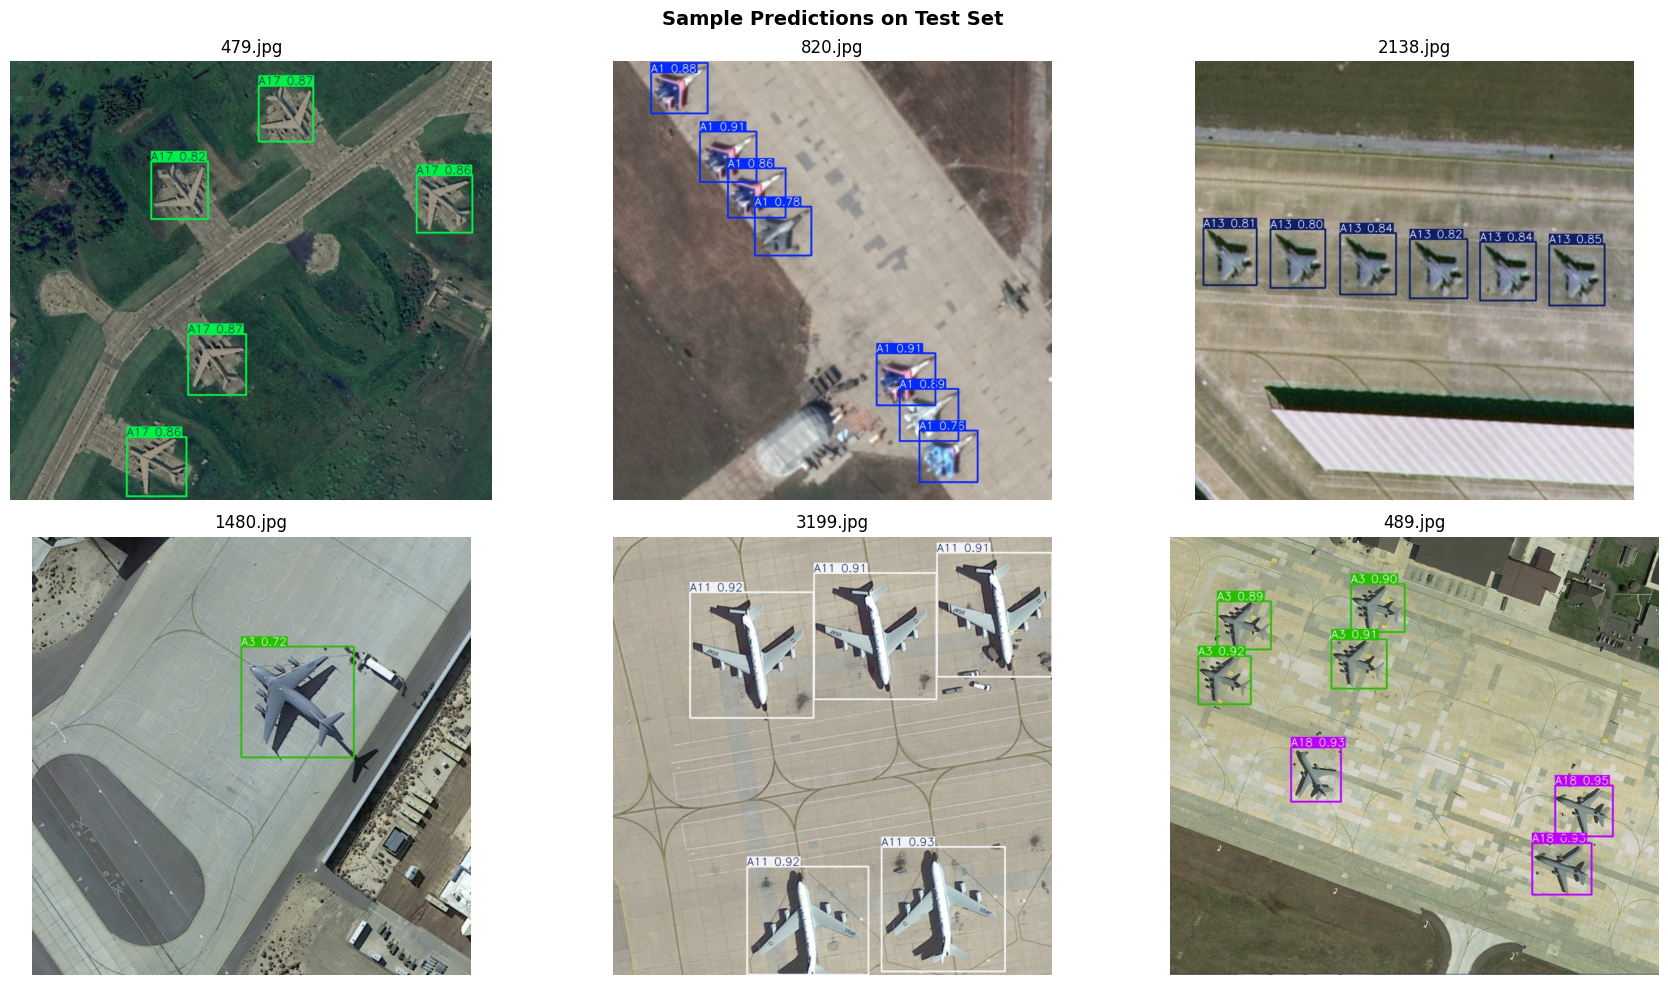

In [41]:
prediction_path = '/content/runs/detect/predict'
files = [f for f in os.listdir(prediction_path) if f.endswith('.jpg')]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Sample Predictions on Test Set", fontsize=14, fontweight='bold')

for ax, fname in zip(axes.flatten(), files[:6]):
    img = Image.open(os.path.join(prediction_path, fname))
    ax.imshow(img)
    ax.set_title(fname)
    ax.axis('off')

plt.tight_layout()
plt.show()

**Locate YOLO Training Results Folder**

In [52]:
runs_dir = "/content/runs/detect"

print(os.listdir(runs_dir))

['predict', 'val-3', 'train', 'val-2', 'val']


**Load Training Results**

In [53]:
results_path = "/content/runs/detect/train/results.csv"

df = pd.read_csv(results_path)
df.columns = df.columns.str.strip()   # ← add this line
df.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,90.9668,1.46240,3.15817,1.27602,0.30624,0.31744,0.19390,0.11972,1.21557,2.38686,1.19842,0.000331,0.000331,0.067196
1,2,159.3430,1.36097,2.26021,1.23998,0.37249,0.58431,0.45032,0.30088,1.11950,1.63432,1.09220,0.000643,0.000643,0.034174
2,3,225.4220,1.31735,1.89173,1.22506,0.46043,0.65344,0.55667,0.37811,1.11088,1.41393,1.08714,0.000932,0.000932,0.001131
3,4,289.8360,1.27529,1.68492,1.20093,0.55163,0.69469,0.64101,0.43855,1.07645,1.23232,1.07176,0.000901,0.000901,0.000901
4,5,355.9150,1.23477,1.54362,1.18842,0.60182,0.74184,0.73715,0.50896,1.08696,1.04894,1.06658,0.000868,0.000868,0.000868


**All Training Plots Combined**

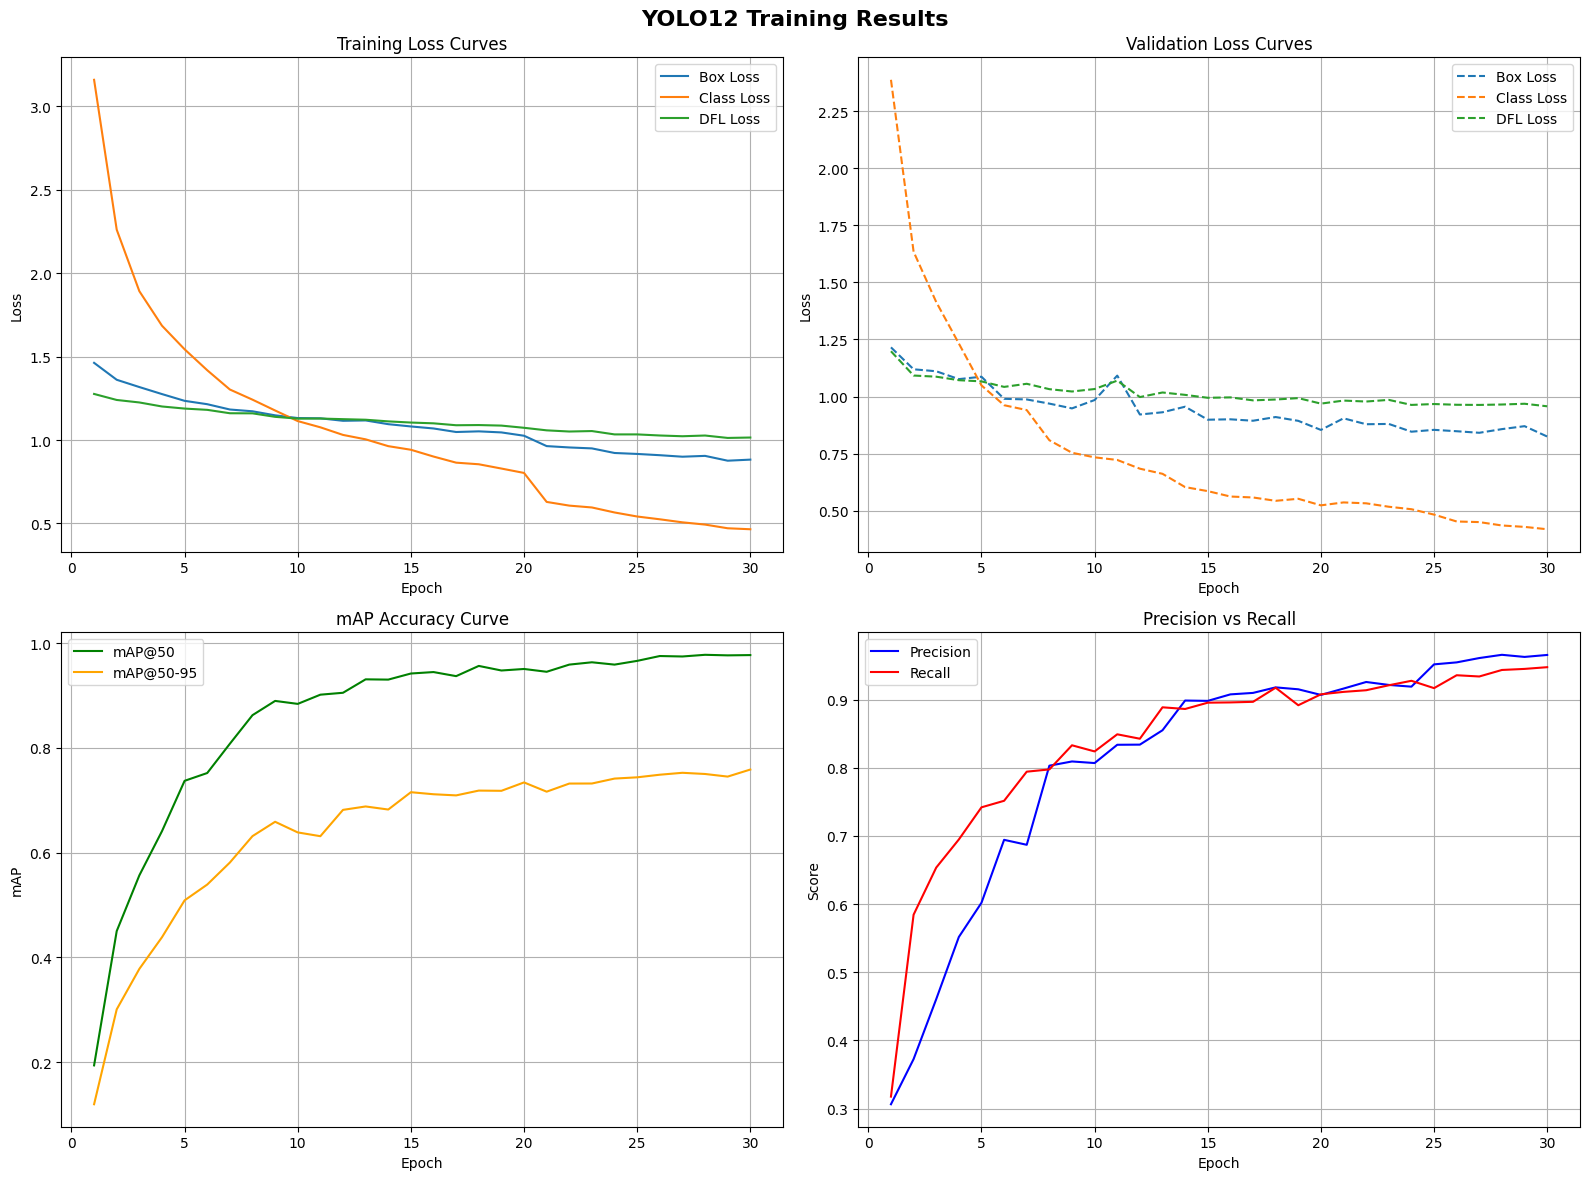

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("YOLO12 Training Results", fontsize=16, fontweight='bold')

# Training Loss
axes[0, 0].plot(df['epoch'], df['train/box_loss'], label='Box Loss')
axes[0, 0].plot(df['epoch'], df['train/cls_loss'], label='Class Loss')
axes[0, 0].plot(df['epoch'], df['train/dfl_loss'], label='DFL Loss')
axes[0, 0].set_title("Training Loss Curves")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()
axes[0, 0].grid()

# Validation Loss
axes[0, 1].plot(df['epoch'], df['val/box_loss'], label='Box Loss', linestyle='--')
axes[0, 1].plot(df['epoch'], df['val/cls_loss'], label='Class Loss', linestyle='--')
axes[0, 1].plot(df['epoch'], df['val/dfl_loss'], label='DFL Loss', linestyle='--')
axes[0, 1].set_title("Validation Loss Curves")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()
axes[0, 1].grid()

# mAP
axes[1, 0].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50', color='green')
axes[1, 0].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@50-95', color='orange')
axes[1, 0].set_title("mAP Accuracy Curve")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("mAP")
axes[1, 0].legend()
axes[1, 0].grid()

# Precision & Recall
axes[1, 1].plot(df['epoch'], df['metrics/precision(B)'], label='Precision', color='blue')
axes[1, 1].plot(df['epoch'], df['metrics/recall(B)'], label='Recall', color='red')
axes[1, 1].set_title("Precision vs Recall")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Score")
axes[1, 1].legend()
axes[1, 1].grid()

plt.tight_layout()
plt.savefig("training_results.png", dpi=150)
plt.show()

**Confusion Matrix**

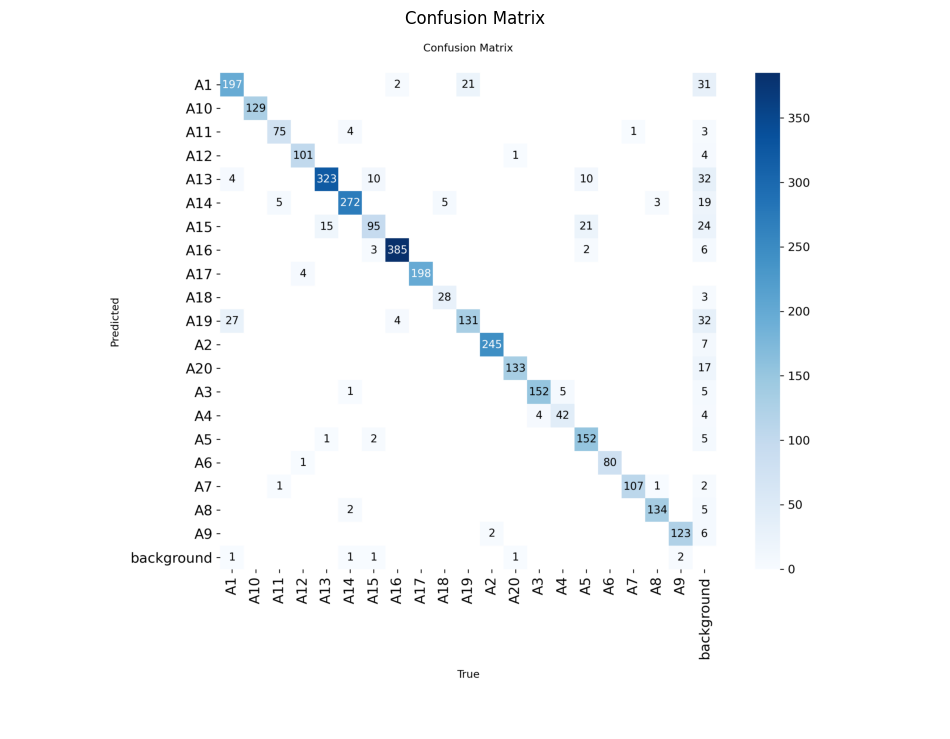

In [55]:
conf_matrix_path = "/content/runs/detect/train/confusion_matrix.png"
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(conf_matrix_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,10))
plt.imshow(img)
plt.axis("off")
plt.title("Confusion Matrix")
plt.show()

**Confusion Matrix (Normalized Version)**

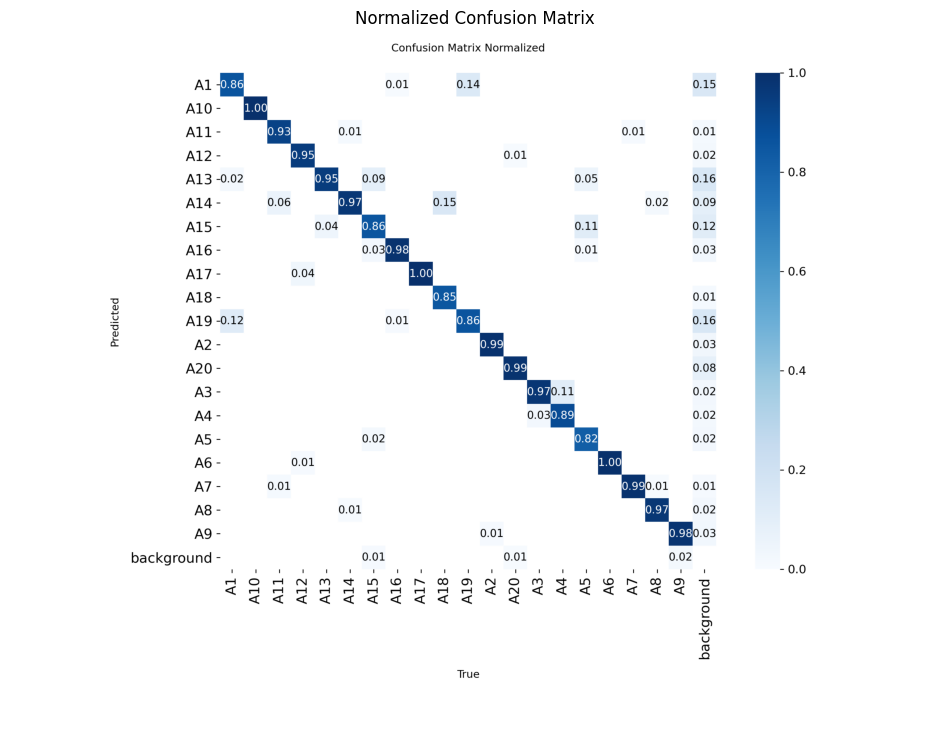

In [56]:
conf_matrix_norm_path = "/content/runs/detect/train/confusion_matrix_normalized.png"

img = cv2.imread(conf_matrix_norm_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,10))
plt.imshow(img)
plt.axis("off")
plt.title("Normalized Confusion Matrix")
plt.show()

**Val vs Test Comparison**

In [57]:
print(f"{'Metric':<20} {'Validation':>12} {'Test (Unseen)':>14}")
print("-" * 48)
print(f"{'mAP@50':<20} {val_metrics.box.map50:>12.4f} {test_metrics.box.map50:>14.4f}")
print(f"{'mAP@50-95':<20} {val_metrics.box.map:>12.4f} {test_metrics.box.map:>14.4f}")
print(f"{'Precision':<20} {val_metrics.box.mp:>12.4f} {test_metrics.box.mp:>14.4f}")
print(f"{'Recall':<20} {val_metrics.box.mr:>12.4f} {test_metrics.box.mr:>14.4f}")

Metric                 Validation  Test (Unseen)
------------------------------------------------
mAP@50                     0.9770         0.9714
mAP@50-95                  0.7608         0.7596
Precision                  0.9690         0.9497
Recall                     0.9424         0.9311


**Model Performance Summary**

In [58]:
best_row = df.loc[df['metrics/mAP50(B)'].idxmax()]

print("=== Best Epoch (from Training) ===")
print("Best Epoch    :", int(best_row['epoch']))
print("mAP@50        :", round(best_row['metrics/mAP50(B)'], 4))
print("mAP@50-95     :", round(best_row['metrics/mAP50-95(B)'], 4))
print("Precision     :", round(best_row['metrics/precision(B)'], 4))
print("Recall        :", round(best_row['metrics/recall(B)'], 4))

print("\n=== Final Test Set (Unseen Data) ===")
print("mAP@50        :", round(test_metrics.box.map50, 4))
print("mAP@50-95     :", round(test_metrics.box.map, 4))
print("Precision     :", round(test_metrics.box.mp, 4))
print("Recall        :", round(test_metrics.box.mr, 4))

=== Best Epoch (from Training) ===
Best Epoch    : 28
mAP@50        : 0.9777
mAP@50-95     : 0.7502
Precision     : 0.9656
Recall        : 0.9434

=== Final Test Set (Unseen Data) ===
mAP@50        : 0.9714
mAP@50-95     : 0.7596
Precision     : 0.9497
Recall        : 0.9311


In [59]:
import zipfile
import os
from google.colab import files

zip_path = '/content/yolo12_results.zip'

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:

    # 1. YAML file
    zipf.write(
        '/content/yolo_dataset/dataset.yaml',
        'dataset.yaml'
    )

    # 2. Cleaned dataset (images + annotations)
    for folder, subfolder in [
        ('/content/cleaned_dataset/images', 'cleaned_dataset/images'),
        ('/content/cleaned_dataset/annotations', 'cleaned_dataset/annotations')
    ]:
        for fname in os.listdir(folder):
            zipf.write(
                os.path.join(folder, fname),
                os.path.join(subfolder, fname)
            )

    # 3. YOLO dataset (train/val/test images + labels)
    for split in ['train', 'val', 'test']:
        for kind in ['images', 'labels']:
            folder = f'/content/yolo_dataset/{kind}/{split}'
            for fname in os.listdir(folder):
                zipf.write(
                    os.path.join(folder, fname),
                    f'yolo_dataset/{kind}/{split}/{fname}'
                )

    # 4. Training results (weights, plots, curves)
    results_dir = '/content/runs/detect/train'
    for root_dir, dirs, fnames in os.walk(results_dir):
        for fname in fnames:
            full_path = os.path.join(root_dir, fname)
            arcname = full_path.replace('/content/', '')
            zipf.write(full_path, arcname)

    # 5. Training results plot
    if os.path.exists('/content/training_results.png'):
        zipf.write(
            '/content/training_results.png',
            'training_results.png'
        )

print("✅ Zip created successfully!")
print(f"📦 Size: {os.path.getsize(zip_path) / (1024*1024):.2f} MB")

files.download(zip_path)

✅ Zip created successfully!
📦 Size: 2313.59 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📂 Select an image from your PC...


Saving military_plane2.jpg to military_plane2 (1).jpg

image 1/1 /content/military_plane2 (1).jpg: 448x640 3 A1s, 18.1ms
Speed: 2.2ms preprocess, 18.1ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/custom_predict


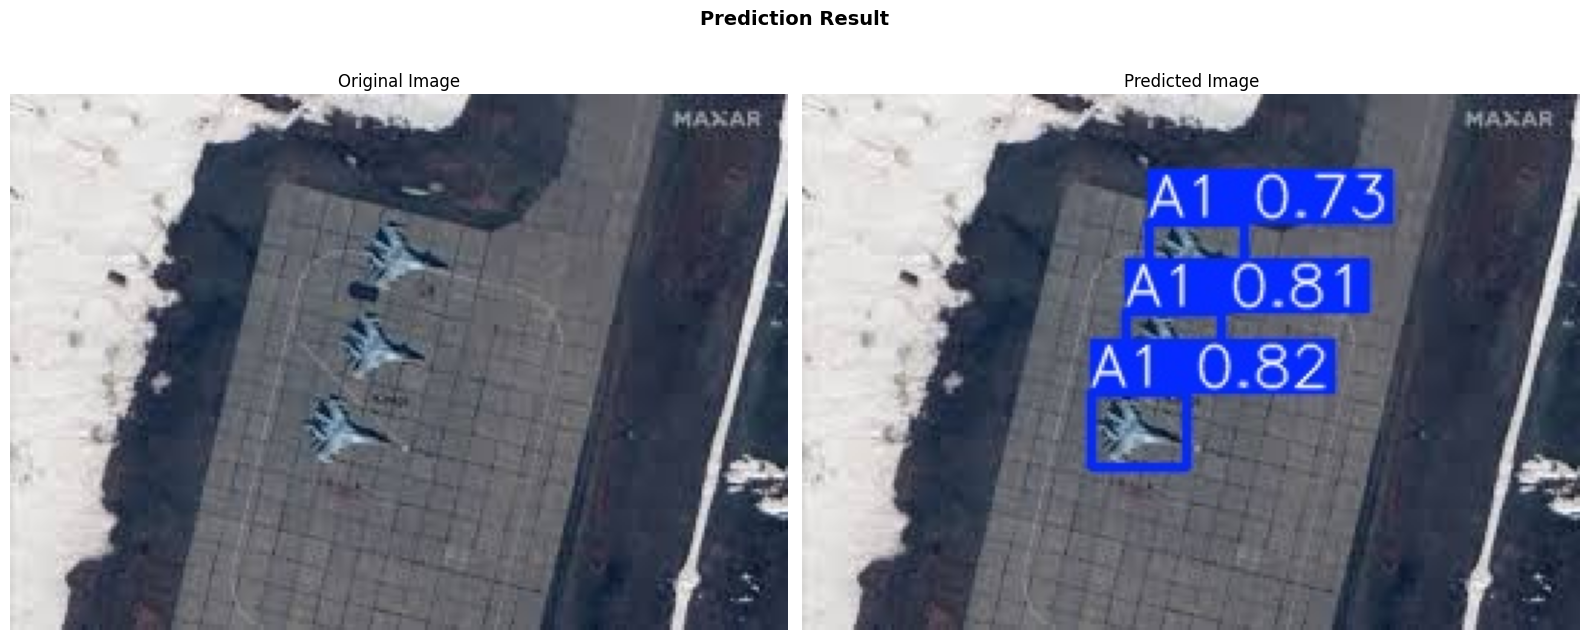


=== Detection Results ===
✅ Military aircraft detected: 3
#     Class                  Confidence Bounding Box
----------------------------------------------------------------------
1     A1                        81.69%  [100.7, 103.6, 133.3, 129.5]
2     A1                        81.33%  [112.6, 75.2, 145.7, 98.9]
3     A1                        73.10%  [120.8, 44.0, 154.0, 67.3]


In [68]:
from google.colab import files
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
import os

# 1. Upload image from your PC
print("📂 Select an image from your PC...")
uploaded = files.upload()

# 2. Get the uploaded filename
image_name = list(uploaded.keys())[0]
image_path = f'/content/{image_name}'

# 3. Load best model (skip if already loaded)
model = YOLO("/content/runs/detect/train/weights/best.pt")

# 4. Run prediction
results = model.predict(
    source=image_path,
    conf=0.55,
    save=True,
    save_dir='/content/runs/detect/custom_predict'
)


# 5. Display original vs predicted side by side
predicted_path = f'/content/runs/detect/custom_predict/{image_name}'

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Prediction Result", fontsize=14, fontweight='bold')

# Original
original = Image.open(image_path)
axes[0].imshow(original)
axes[0].set_title("Original Image")
axes[0].axis('off')

# Predicted
predicted = Image.open(predicted_path)
axes[1].imshow(predicted)
axes[1].set_title("Predicted Image")
axes[1].axis('off')

plt.tight_layout()
plt.show()

# 6. Print detection details
# After prediction, replace your print section with this

print("\n=== Detection Results ===")
for result in results:
    boxes = result.boxes

    if boxes is None or len(boxes) == 0:
        print("⚠️  No aircraft detected.")
    else:
        high_conf_boxes = [b for b in boxes if float(b.conf[0]) >= 0.55]

        if len(high_conf_boxes) == 0:
            print("⚠️  Aircraft detected but confidence is too low.")
            print("    This may be a civilian/non-military aircraft.")
            print("    Model is trained on military aircraft only.")
        else:
            print(f"✅ Military aircraft detected: {len(high_conf_boxes)}")
            print(f"{'#':<5} {'Class':<20} {'Confidence':>12} {'Bounding Box'}")
            print("-" * 70)
            for i, box in enumerate(high_conf_boxes):
                class_id   = int(box.cls[0])
                class_name = model.names[class_id]
                confidence = float(box.conf[0])
                coords     = box.xyxy[0].tolist()
                print(f"{i+1:<5} {class_name:<20} {confidence:>11.2%}  {[round(c,1) for c in coords]}")